In [1]:
import pandas as pd

In [2]:
data=pd.read_csv(r"D:\Desktop\online_retail.csv")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
273114,560780,21790,VINTAGE SNAP CARDS,1,21-07-2011 09:31,1.63,NaN,United Kingdom
273115,560780,21908,CHOCOLATE THIS WAY METAL SIGN,1,21-07-2011 09:31,4.13,NaN,United Kingdom
273116,560780,21928,JUMBO BAG SCANDINAVIAN BLUE PAISLEY,1,21-07-2011 09:31,4.13,NaN,United Kingdom
273117,560780,21929,JUMBO BAG PINK VINTAGE PAISLEY,2,21-07-2011 09:31,4.13,NaN,United Kingdom


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273119 entries, 0 to 273118
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    273119 non-null  object 
 1   StockCode    273119 non-null  object 
 2   Description  272960 non-null  object 
 3   Quantity     273119 non-null  int64  
 4   InvoiceDate  273119 non-null  object 
 5   UnitPrice    273119 non-null  float64
 6   CustomerID   247259 non-null  float64
 7   Country      273119 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 16.7+ MB


In [4]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
data.duplicated().sum()

np.int64(3156)

In [6]:
data.shape

(273119, 8)

In [7]:
data = data.drop_duplicates()
data.shape

(269963, 8)

In [8]:
data = data.drop_duplicates()
print(data.duplicated().sum())

0


In [9]:
data.isnull().sum()

InvoiceNo          0
StockCode          0
Description      159
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     25848
Country            0
dtype: int64

In [10]:
data = data.dropna(subset=['CustomerID'])

In [11]:
data = data.dropna(subset=['Description'])

In [12]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
#adding a new column Revenue(Feature engineering)
data['Revenue'] = data['Quantity'] * data['UnitPrice']

In [14]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [15]:
#checking possible outliers
data['Revenue'].describe()


count    244115.000000
mean         18.886970
std         503.741944
min     -168469.600000
25%           3.750000
50%           9.900000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [16]:
#KPI Analysis
sales_data = data[(data['Quantity'] > 0) & (data['Revenue'] > 0)]

In [17]:
sales_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [18]:
sales_data['Country'].value_counts().head(10)

Country
United Kingdom    216988
France              4548
Germany             4201
EIRE                4061
Spain               1168
Netherlands         1124
Belgium             1047
Switzerland          968
Portugal             869
Norway               727
Name: count, dtype: int64

In [19]:
#Top selling products
sales_data['Description'].value_counts().head(10)

Description
PAPER CHAIN KIT 50'S CHRISTMAS        891
JUMBO BAG RED RETROSPOT               855
WHITE HANGING HEART T-LIGHT HOLDER    830
RABBIT NIGHT LIGHT                    799
HOT WATER BOTTLE KEEP CALM            740
REGENCY CAKESTAND 3 TIER              726
GARDENERS KNEELING PAD KEEP CALM      666
ASSORTED COLOUR BIRD ORNAMENT         648
POPCORN HOLDER                        633
PAPER CHAIN KIT VINTAGE CHRISTMAS     629
Name: count, dtype: int64

In [20]:
sales_data.shape

(239167, 9)

In [21]:
sales_data['Revenue'].sum()

np.float64(5040131.462)

In [22]:
sales_data['CustomerID'].nunique()

3595

In [23]:
sales_data['InvoiceNo'].nunique()

9211

In [24]:
#top customers
sales_data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

CustomerID
18102.0    182552.94
16446.0    168469.60
14646.0    125498.25
17450.0    118570.43
14911.0     86210.87
14096.0     65256.15
12415.0     49278.14
17511.0     47461.36
14156.0     42557.20
15098.0     39916.50
Name: Revenue, dtype: float64

In [25]:
#Customer spend in total(Average customer value)
sales_data.groupby('CustomerID')['Revenue'].sum().mean()

np.float64(1401.983716828929)

In [26]:
#Average order value AOV
sales_data.groupby('InvoiceNo')['Revenue'].sum().mean()

np.float64(547.1861320160677)

In [27]:
#Top countries by revenue
sales_data.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    4275497.812
Netherlands        126289.450
EIRE               123088.400
France             116988.470
Germany            103552.470
Australia           55938.450
Switzerland         33157.080
Spain               30238.390
Norway              27057.220
Belgium             22242.930
Name: Revenue, dtype: float64

In [28]:
sales_data.groupby('Country')['Revenue'].sum().mean()

np.float64(152731.25642424246)

In [29]:
#Top selling products
sales_data['Description'].value_counts().head(10)

Description
PAPER CHAIN KIT 50'S CHRISTMAS        891
JUMBO BAG RED RETROSPOT               855
WHITE HANGING HEART T-LIGHT HOLDER    830
RABBIT NIGHT LIGHT                    799
HOT WATER BOTTLE KEEP CALM            740
REGENCY CAKESTAND 3 TIER              726
GARDENERS KNEELING PAD KEEP CALM      666
ASSORTED COLOUR BIRD ORNAMENT         648
POPCORN HOLDER                        633
PAPER CHAIN KIT VINTAGE CHRISTMAS     629
Name: count, dtype: int64

In [30]:
#Monthly growth or revenue
sales_data = data[(data['Quantity'] > 0) & (data['Revenue'] > 0)].copy()
sales_data['InvoiceDate'] = pd.to_datetime(sales_data['InvoiceDate'], dayfirst=True) 
sales_data['Month'] = sales_data['InvoiceDate'].dt.to_period('M')
monthly_revenue = sales_data.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

Month
2010-12        150.220
2011-06     610064.680
2011-07     363434.370
2011-09     846214.642
2011-10    1125428.530
2011-11    1463855.640
2011-12     630983.380
Freq: M, Name: Revenue, dtype: float64


In [31]:
#Monthly revenue to dataframe
monthly_revenue = ( sales_data.groupby('Month')['Revenue'].sum().reset_index())
monthly_revenue.columns = ['Month', 'Total_Revenue']
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)
monthly_revenue


,Month,Total_Revenue
0,2010-12,150.220
1,2011-06,610064.680
2,2011-07,363434.370
3,2011-09,846214.642
4,2011-10,1125428.530
5,2011-11,1463855.640
6,2011-12,630983.380


In [32]:
import matplotlib.pyplot as plt

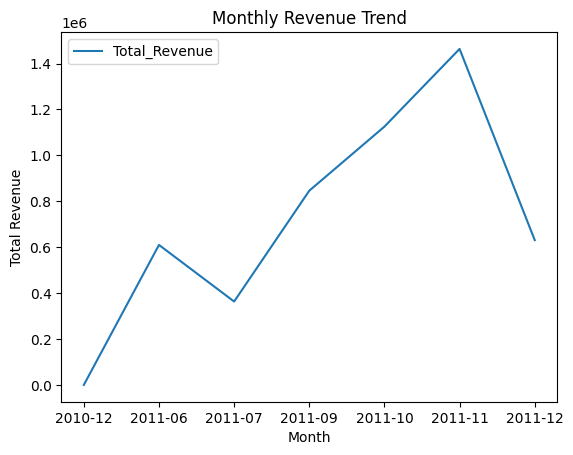

In [33]:
monthly_revenue.plot(x='Month', y='Total_Revenue', kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

In [34]:
analysis = {
    "Period Start": monthly_revenue['Month'].min(),
    "Period End": monthly_revenue['Month'].max(),
    "Highest Month": monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmax(), 'Month'],
    "Lowest Month": monthly_revenue.loc[monthly_revenue['Total_Revenue'].idxmin(),'Month'],
    "Average Revenue": monthly_revenue['Total_Revenue'].mean()
}

for k,v in analysis.items():
    print(f"{k}:{v}")

Period Start:2010-12
Period End:2011-12
Highest Month:2011-11
Lowest Month:2010-12
Average Revenue:720018.7802857142


In [35]:
#RFM matrix

In [36]:
sales_data = data[(data['Quantity'] > 0) & (data['Revenue'] > 0)].copy()
sales_data['InvoiceDate'] = pd.to_datetime(sales_data['InvoiceDate'], dayfirst=True)
reference_date = sales_data['InvoiceDate'].max()


In [37]:
#rfm matrix (group by customers)
rfm = sales_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [38]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,1,3,1901.66
12348.0,44,2,333.94
12349.0,18,1,1757.55
12352.0,35,4,1085.75
12353.0,23,1,16.16


In [39]:
#RFM scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12347.0,1,3,1901.66,5,4,5
12348.0,44,2,333.94,2,3,2
12349.0,18,1,1757.55,3,1,5
12352.0,35,4,1085.75,2,4,4
12353.0,23,1,16.16,3,1,1


In [40]:
#RFM score combining
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)+
    rfm['F_Score'].astype(str)+
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12347.0,1,3,1901.66,5,4,5,545
12348.0,44,2,333.94,2,3,2,232
12349.0,18,1,1757.55,3,1,5,315
12352.0,35,4,1085.75,2,4,4,244
12353.0,23,1,16.16,3,1,1,311


In [41]:
#RFM segmentation
#Champions , High recency (5)  ,High frequency (4-5), High monetary (4-5)
rfm[(rfm['R_Score'] ==5) & (rfm['F_Score'] >=4) & (rfm['M_Score'] >=4)]

#Loyal customers(frequent buyers and good spenders)
rfm[(rfm['R_Score'] >=3) & (rfm['F_Score'] >=4)  & (rfm['M_Score'] >=3)]

#Potential loyalists , not frequnent buyers yet
rfm[(rfm['R_Score'] >=4) & (rfm['F_Score'] <=3)  & (rfm['M_Score'] >=2)]

#At risk customers
rfm[(rfm['R_Score'] <=2) & (rfm['F_Score'] >=2)]

#Lost customers
rfm[(rfm['R_Score'] <=2) & (rfm['F_Score'] <=2) & (rfm['M_Score'] <=2)]


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12353.0,23,1,16.16,3,1,1,311
12356.0,22,1,58.35,3,1,1,311
12367.0,3,1,168.90,5,1,1,511
12384.0,28,1,292.58,3,1,2,312
12414.0,30,1,65.66,3,1,1,311
...,...,...,...,...,...,...,...
18040.0,18,1,118.20,3,2,1,321
18042.0,53,1,165.05,2,2,1,221
18043.0,24,1,107.70,3,2,1,321


In [42]:
def segment_customer(row):

    if row['R_Score'] == 5 and row['F_Score'] >=4 and row['M_Score'] >=4:
        return 'Champions'

    elif row['R_Score'] >=3 and row['F_Score'] >=4  and row['M_Score'] >=3:
        return 'Loyal Customers'

    elif row['R_Score'] >=4 and row['F_Score'] <=3 and row['M_Score'] >=2:
        return 'Potential Customers'

    elif row['R_Score'] <=2 and row['F_Score'] >=2:
        return 'At Risk'

    elif row['R_Score'] <=2 and row['F_Score'] <=2 and row ['M_Score'] <=2:
        return 'Lost Customers'

    else:
        return 'Others'
    
    
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
At Risk                974
Others                 801
Loyal Customers        728
Champions              449
Potential Customers    329
Lost Customers         314
Name: count, dtype: int64

In [43]:
#Segment distribution
rfm['Segment'].value_counts(normalize=True) * 100

Segment
At Risk                27.093185
Others                 22.280946
Loyal Customers        20.250348
Champions              12.489569
Potential Customers     9.151599
Lost Customers          8.734353
Name: proportion, dtype: float64

In [44]:
#Revenue contribution per segment(who brings money)
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions              2281568.350
Loyal Customers        1280353.230
At Risk                 629936.791
Others                  406738.181
Potential Customers     382631.300
Lost Customers           58903.610
Name: Monetary, dtype: float64

In [45]:
#segment profiling or behavior profiling (customer behavior)
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,74.481520,1.728953,646.752352
Champions,1.726058,9.160356,5081.443987
Lost Customers,89.770701,1.000000,187.591115
Loyal Customers,14.625000,4.605769,1758.726964
Others,29.841448,1.399501,507.787991
Potential Customers,7.294833,1.647416,1163.013070


In [46]:
#String to int
rfm['RFM_Score_Num'] = (
    rfm['R_Score'].astype(int)+
    rfm['F_Score'].astype(int)+
    rfm['M_Score'].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,RFM_Score_Num
CustomerID,,,,,,,,,
12347.0,1,3,1901.66,5,4,5,545,Champions,14
12348.0,44,2,333.94,2,3,2,232,At Risk,7
12349.0,18,1,1757.55,3,1,5,315,Others,9
12352.0,35,4,1085.75,2,4,4,244,At Risk,10
12353.0,23,1,16.16,3,1,1,311,Others,5


In [47]:
threshold = rfm['RFM_Score_Num'].median()

rfm['Value_Group'] = rfm['RFM_Score_Num'].apply(
    lambda x: 'High Value Customers' if x >= threshold else 'Low Value Customers'
)

In [48]:
rfm['Value_Group'].value_counts()

Value_Group
High Value Customers    1843
Low Value Customers     1752
Name: count, dtype: int64

In [49]:
#Behavior analysis
rfm.groupby('Value_Group')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Value_Group,,,
High Value Customers,14.773738,4.895822,2428.118785
Low Value Customers,63.487443,1.200913,322.550538


In [50]:
rfm.groupby('Value_Group')['Monetary'].sum()

Value_Group
High Value Customers    4475022.920
Low Value Customers      565108.542
Name: Monetary, dtype: float64

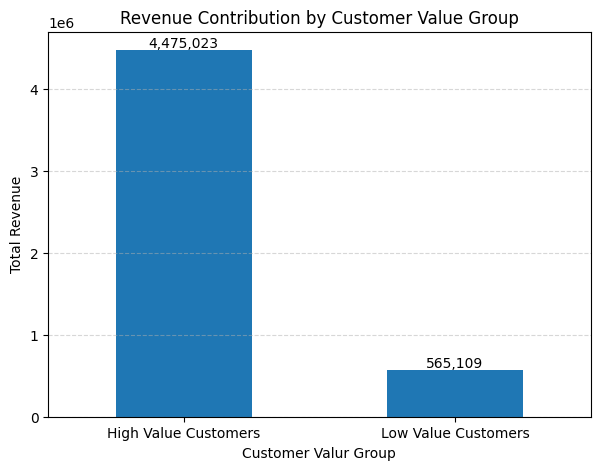

In [51]:
#Revenue visualization
chart = rfm.groupby('Value_Group')['Monetary'].sum().plot(kind='bar', figsize=(7,5))
plt.title('Revenue Contribution by Customer Value Group')
plt.xlabel('Customer Valur Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle='--', alpha=0.5)

for p in chart.patches:
    chart.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

In [52]:
#exporting to MySQL 
rfm.to_csv("rfm_final.csv", index=True)